Original Data:
    sales
0     100
1     105
2      98
3     110
4      95
5     500
6     102
7      97
8     108
9    1000
10    103
11     99
12    107

Detected Outliers (IQR method):
   sales
5    500
9   1000


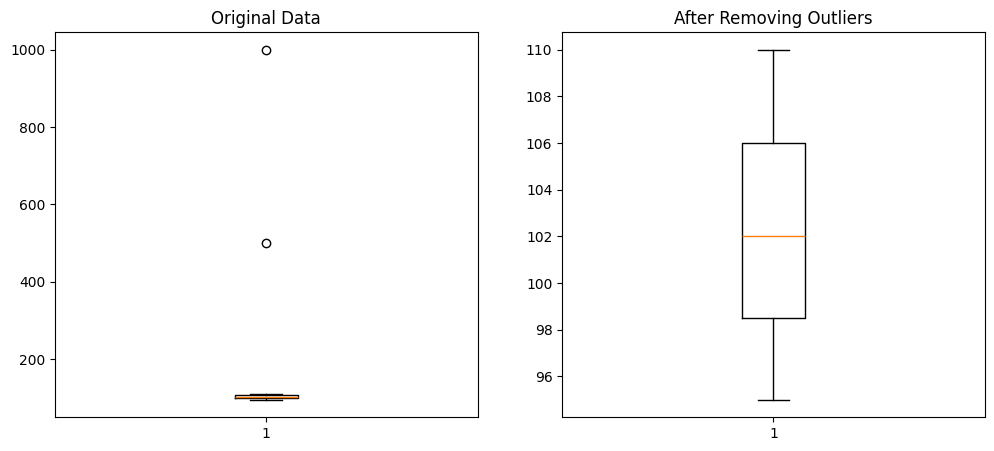

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset
data = {
    "sales": [100, 105, 98, 110, 95, 500, 102, 97, 108, 1000, 103, 99, 107]
}
df = pd.DataFrame(data)

print("Original Data:")
print(df)

# ---------------------------
# 1. Detect outliers using IQR
# ---------------------------
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["sales"] < lower_bound) | (df["sales"] > upper_bound)]
print("\nDetected Outliers (IQR method):")
print(outliers)

# ---------------------------
# 2. Handle outliers
# ---------------------------

# (A) Remove outliers
df_removed = df[(df["sales"] >= lower_bound) & (df["sales"] <= upper_bound)]

# (B) Cap outliers (Winsorization)
df_capped = df.copy()
df_capped["sales"] = np.where(df_capped["sales"] > upper_bound, upper_bound,
                              np.where(df_capped["sales"] < lower_bound, lower_bound, df_capped["sales"]))

# (C) Impute with Median
median_val = df["sales"].median()
df_imputed = df.copy()
df_imputed.loc[(df_imputed["sales"] < lower_bound) | (df_imputed["sales"] > upper_bound), "sales"] = median_val

# ---------------------------
# 3. Visualization
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(df["sales"])
plt.title("Original Data")

plt.subplot(1,2,2)
plt.boxplot(df_removed["sales"])
plt.title("After Removing Outliers")

plt.show()
